In [1]:
using TensorKit, MPSKit, MPSKitModels, ProgressMeter, JLD2, LaTeXStrings, CairoMakie, ImageMagick
grad = cgrad(:acton50);

  Activating project at `~/work/April7/Working_env`
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] 
[ Info: Precompiling IntervalArithmeticRecipesBaseExt [e3b91bd4-2888-5303-85ed-4cf5ebb38ff1] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling ImageMagick [6218d12a-5da1-5696-b52f-db25d2ecc6d1] (cache misses: wrong dep version loaded (2))


In [2]:
function to_index(x,y,W)
    return y+W*(x-1)
end

function to_cartesian(n,W,L1)
    x = (n+W-1)÷W
    if x <= L1+1
        y = mod1(n%W,W)
    elseif (x- L1)%2 == 0
        y = mod1(n%W,W)
    else
        y = mod1(n%W,W) + 0.5
    end
    if x > L1+1
        x = L1 + 1 + 0.5*(x-L1)
    end
    return [x, y]
end

to_cartesian (generic function with 1 method)

In [3]:
W = 5
L1 = 6
δt = 0.05
t_list = collect(1:121)*δt

Xs_list  = load_object("2d_data.jld2")
string_data = load_object("Wilson_Loop_data.jld2")
Lx = size(Xs_list[1,:])[1]÷W;

In [4]:
d = Xs_list[1,:]
xs = [to_cartesian(i,W,L1)[1] for i=1:length(d)]
ys = [to_cartesian(i,W,L1)[2] for i=1:length(d)];

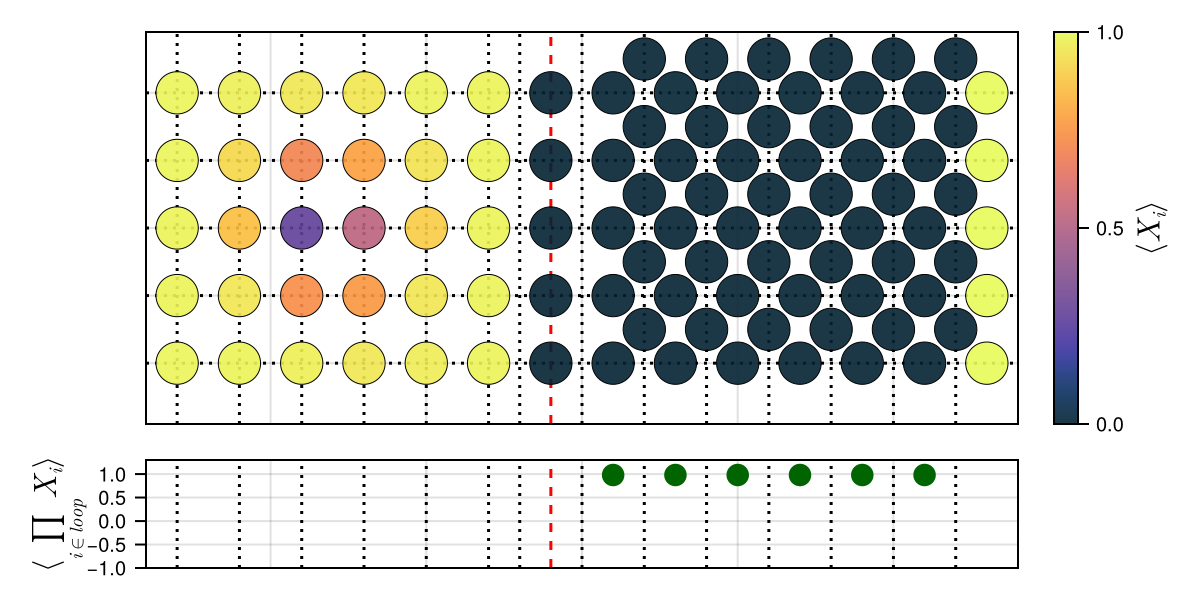

In [5]:
i=1
t = round(δt * i; digits = 3)
d = Xs_list[i, :]          # same as before

fig = Figure(size = (600, 300))

########################################
# Top panel
########################################
ax1 = Axis(fig[1:3, 1:10];
    xlabel = "",
    ylabel = "",
    xticksvisible = false,
    yticksvisible = false,
    xticklabelsvisible = false,
    yticklabelsvisible = false,
)

xlims!(ax1, 0.5, 2L1 + 2.5)
ylims!(ax1, 0.1, 5.9)

# dotted guide lines
hlines!(ax1, 1:5;  color = :black, linestyle = :dot)
vlines!(ax1, 1:6;  color = :black, linestyle = :dot)
vlines!(ax1, L1 .+ (0.5:1:7.5); color = :black, linestyle = :dot)

# red dashed interface
vlines!(ax1, [L1 + 1]; color = :red, linestyle = :dash)

# colored scatter
sc = scatter!(ax1, xs, ys;
    color     = d,
    colormap  = :thermal,      # pick your favourite cmap
    markersize = 30,
    strokewidth = 0.5,
    alpha=0.9,
    colorrange=(0,1)
)

# colorbar for top panel
Colorbar(fig[1:3, 11], sc; label=latexstring(L"\langle X_i \rangle"),ticklabelsize =10,labelsize=16,halign=:left)

########################################
# Bottom panel
########################################
ax2 = Axis(fig[4, 1:10];
    xlabel = "",
    ylabel = latexstring(L"\langle\prod_{i\in loop} X_i\rangle"),
    xticksvisible = false,
    yticksvisible = true,
    xticklabelsvisible = false,
    # yaxisposition = :right,
    yticklabelsize = 10,
    ylabelsize=16,
    ylabelpadding = 0
)
linkxaxes!(ax1,ax2)

xlims!(ax2, 0.5, 2L1 + 2.5)
ylims!(ax2, -1, 1.3)

vlines!(ax2, 1:6;  color = :black, linestyle = :dot)
vlines!(ax2, L1 .+ (0.5:1:7.5); color = :black, linestyle = :dot)

scatter!(ax2,
    L1 + 1 .+ collect(1:6),
    string_data[i];
    markersize = 16,
    color = :darkgreen,
)
vlines!(ax2, [L1 + 1]; color = :red, linestyle = :dash)
fig

In [6]:
for i=1:100
t = round(δt * i; digits = 3)
d = Xs_list[i, :]          # same as before

fig = Figure(size = (600, 300))

########################################
# Top panel
########################################
ax1 = Axis(fig[1:3, 1:10];
    xlabel = "",
    ylabel = "",
    xticksvisible = false,
    yticksvisible = false,
    xticklabelsvisible = false,
    yticklabelsvisible = false,
)

xlims!(ax1, 0.5, 2L1 + 2.5)
ylims!(ax1, 0.1, 5.9)

# dotted guide lines
hlines!(ax1, 1:5;  color = :black, linestyle = :dot)
vlines!(ax1, 1:6;  color = :black, linestyle = :dot)
vlines!(ax1, L1 .+ (0.5:1:7.5); color = :black, linestyle = :dot)

# red dashed interface
vlines!(ax1, [L1 + 1]; color = :red, linestyle = :dash)

# colored scatter
sc = scatter!(ax1, xs, ys;
    color     = d,
    colormap  = :thermal,      # pick your favourite cmap
    markersize = 30,
    strokewidth = 0.5,
    alpha=0.9,
    colorrange=(0,1)
)

# colorbar for top panel
Colorbar(fig[1:3, 11], sc; label=latexstring(L"\langle X_i \rangle"),ticklabelsize =10,labelsize=16,halign=:left)

########################################
# Bottom panel
########################################
ax2 = Axis(fig[4, 1:10];
    xlabel = "",
    ylabel = latexstring(L"\langle\prod_{i\in loop} X_i\rangle"),
    xticksvisible = false,
    yticksvisible = true,
    xticklabelsvisible = false,
    # yaxisposition = :right,
    yticklabelsize = 10,
    ylabelsize=16,
    ylabelpadding = 0
)
linkxaxes!(ax1,ax2)

xlims!(ax2, 0.5, 2L1 + 2.5)
ylims!(ax2, -1, 1.3)

vlines!(ax2, 1:6;  color = :black, linestyle = :dot)
vlines!(ax2, L1 .+ (0.5:1:7.5); color = :black, linestyle = :dot)

scatter!(ax2,
    L1 + 1 .+ collect(1:6),
    string_data[i];
    markersize = 16,
    color = :darkgreen,
)
vlines!(ax2, [L1 + 1]; color = :red, linestyle = :dash)

save("2d_makie_pngs/fig-$(i).png",fig; px_per_unit = 1.0)
#save("Xs_string_t$(t).png", fig; px_per_unit = 3)
end